# Experiment with the mnist fashion data set

It's recommended that you run this code in the CS63env on our servers, or run it on Google Colab; trying to train models like this on a personal laptop is typically very slow.

It is formatted very similarly to the mnist digit data set.  It has 10 categories of black and white images.

* 0 = t-shirt
* 1 = trouser
* 2 = pullover
* 3 = dress
* 4 = coat
* 5 = sandal
* 6 = shirt
* 7 = sneaker
* 8 = bag
* 9 = ankle boot

In [1]:
#NOTE: if running on google colab, uncomment the following line!
#%pip install aitk --quiet

In [2]:
from aitk.utils import gallery, array_to_image
from aitk.networks import SequentialNetwork, Flatten, Dense, InputLayer, Conv2D, MaxPooling2D
import tensorflow
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical

label_map = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat', 'sandal', 'shirt', 'sneaker', 'bag', 'boot']


2026-04-01 16:22:30.476629: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-01 16:22:31.317570: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775074951.593224 1673178 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775074951.671230 1673178 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775074952.369914 1673178 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

# Get the data
* Download the data
* Explore what you have

In [3]:
(train_x, train_y), (test_x, test_y) = fashion_mnist.load_data()

In [4]:
train_x.shape

(60000, 28, 28)

In [5]:
test_x.shape

(10000, 28, 28)

In [6]:
images = [array_to_image(train_x[i]) for i in range(10)]
bigger = [image.resize((100,100)) for image in images]

9,0,0,3,0
2,7,2,5,5

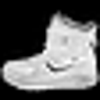
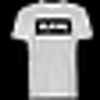
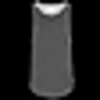
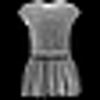
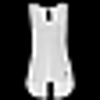
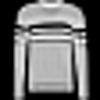
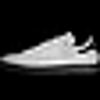
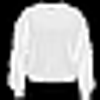
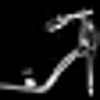
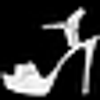

In [7]:
gallery(bigger, gallery_shape=(5,2), labels=train_y[:10])

In [8]:
train_y[:10]

array([9, 0, 0, 3, 0, 2, 7, 2, 5, 5], dtype=uint8)

In [9]:
## Remove some data and reassign labales
print(type(train_y))
print(train_y)
copy = train_y.copy()
train_y = copy

copy = test_y.copy()
test_y = copy

#T-shirt and shirt into pullover
for i, y in enumerate(train_y): 
    if y == 0 or y == 6:
        train_y[i] = 2
for i, y in enumerate(test_y): 
    if y == 0 or y == 6:
        test_y[i] = 2

<class 'numpy.ndarray'>
[9 0 0 ... 3 0 5]


# Prepare the data for the network
* You may need to normalize the inputs so that they are in the range [0,1].
* You may need to convert the targets so that they are represented as one-hot vectors when you are doing categorization.

### Input data

In [10]:
min_input = train_x.min()
max_input = train_x.max()
print("range of input values is:", min_input, max_input)

range of input values is: 0 255


In [11]:
train_x_normalized = (train_x - min_input)/(max_input - min_input)

In [12]:
test_x_normalized = (test_x - min_input)/(max_input - min_input)

### Data sent into a Conv2D layer must have a depth
* This may require you to do a reshape command.
* For these black and white images there is only one channel of information.
* For color images there are typically 3 channels (Red, Green, Blue)

In [13]:
train_x_normalized = train_x_normalized.reshape(60000,28,28,1)
test_x_normalized = test_x_normalized.reshape(10000,28,28,1)

### Target data

In [14]:
num_categories = 10
print(num_categories)

10


In [15]:
train_y_category = to_categorical(train_y, num_categories)

In [16]:
test_y_category = to_categorical(test_y, num_categories)

In [17]:
train_y_category[0]
#print(type(train_y_category[0]))

# for y in train_y_category:
#     if y[6] == 1:
#         print(y)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

# Construct the model

This is just one possible configuration of layers to learn the data set.  You should experiment with the number of filters, the filter size, and the layers themselves. However, be sure to leave the output layer's activation function as `softmax`.

You should explicitly name each layer so that it will be easier to inspect them later. Use a clear naming convention.  For example the first convolution layer might be "conv1", the next "conv2", and so on.

In [18]:
net = SequentialNetwork(
    InputLayer([28,28,1], name="input"),
    Conv2D(filters=8, kernel_size=(5,5), name='conv1'),
    MaxPooling2D(pool_size=(2,2),name='pool1'),
    Flatten(name="flatten"),
    Dense(50, activation='relu', name='hidden'),
    Dense(10, activation='softmax', name='output')
)

net.summary()

2026-04-01 16:22:41.029410: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "SequentialNetwork"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 24, 24, 8)      │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 12, 12, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ (None, 50)             │        57,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,368 (228.00 KB)

 Trainable params: 58,368 (228.00 KB)

 Non-trainable params: 0 (0.00 B)

# Compile the model

For categorical data like handwritten digits we typically use a loss function called `categorical_crossentropy` and should be used in conjunction with the `softmax` activation function at the output layer.  This interprets the outputs as representing probabilities and forces them to sum to 1.0.  Thus the output from the network will reflect how likely it considers a particular input to be a member of one of the output categories.

In [19]:
net.compile(optimizer="SGD", loss="categorical_crossentropy",
            metrics=['accuracy'])

# View the model

Let's propagate a few images through the network to make sure that we have the layers connected up correctly.

In [20]:
from time import sleep
for i in range(10):
    net.propagate(train_x_normalized[i])
    net.display(train_x_normalized[i])
    sleep(1.0)

# Train the model

In [21]:
history = net.fit(train_x_normalized,
                  train_y_category,
                  verbose=1,
                  validation_data=(test_x_normalized,
                            
                                   test_y_category),
                  epochs=15)

Epoch 15/15 accuracy: 0.9325666427612305 - loss: 0.18308252096176147 - val_accuracy: 0.9248999953269958 - val_loss: 0.20966504514217377


Original:
Epoch 5/5 accuracy: 0.8654999732971191 - loss: 0.38115745782852173 - val_accuracy: 0.8579999804496765 - val_loss: 0.3973011374473572 \
Epoch 10/10 accuracy: 0.8866999745368958 - loss: 0.3162757456302643 - val_accuracy: 0.8669999837875366 - val_loss: 0.3688000440597534\
Epoch 15/15 accuracy: 0.899233341217041 - loss: 0.2795703709125519 - val_accuracy: 0.8888000249862671 - val_loss: 0.31772127747535706\
Epoch 20/20 accuracy: 0.9086833596229553 - loss: 0.25232627987861633 - val_accuracy: 0.8906000256538391 - val_loss: 0.30743807554244995

Shirts into Tshirts\
Epoch 10/10 accuracy: 0.9125000238418579 - loss: 0.2485952377319336 - val_accuracy: 0.9018999934196472 - val_loss: 0.27660420536994934\

Shirts and pullover into tshirts\
Epoch 10/10 accuracy: 0.9237833619117737 - loss: 0.2103174477815628 - val_accuracy: 0.9168999791145325 - val_loss: 0.22815170884132385\

Shirts, pullover, and coat into tshirts\
Epoch 10/10 accuracy: 0.902233362197876 - loss: 0.2552575469017029 - val_accuracy: 0.8870000243186951 - val_loss: 0.2779040038585663\

# Evaluate training curves

Look at the curves for both the loss function and the model accuracy.  Here are some things to look for:
* Do decreases in the loss function seem to correspond well with increases in accuracy?   yes
* Does the model appear to be under trained (i.e. both train and test performance looks like it might continue to get better with more epochs)?  it won't be too good, but it could become better little by litter to some extent.
* Does it appear to be over trained (i.e. train performance keeps getting better, but test performance is getting worse as epochs increase)? no
* Are there signs of significant overfitting (i.e. train performance is much higher than test performance, likely worsening as epochs increase)? no

# Inspect the feature maps

We can ask the network to propagate to specific layers and inspect the representations created there to try to understand how it has solved the problem.

In [183]:
test_image = 37# change this to see a different image
sandal, sneakers, boots = [], [], []

for i in range(50):
    if test_y[i] == 5:
        sandal.append(i)
    elif test_y[i] == 7:
        sneakers.append(i)
    elif test_y[i] == 9:
        boots.append(i)

print(sandal)
print(sneakers)
print(boots)


[8, 11, 21, 37]
[9, 12, 22, 36, 38, 43, 45]
[0, 23, 28, 39]


channel0,channel1,channel2,channel3,channel4,channel5,channel6,channel7,channel8

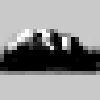
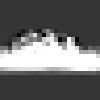
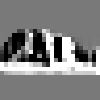
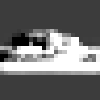
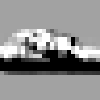
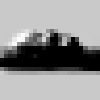
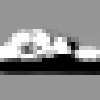
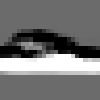

In [184]:
images = [net.propagate_to(test_x_normalized[test_image], "conv1", "image", channel=channel)
         for channel in range(8)]
original = test_x_normalized[test_image]
bigger = [image.resize((100,100),resample=0) for image in images]
gallery([original] + bigger, labels="channel{index}", gallery_shape=(9,1))

channel0,channel1,channel2,channel3,channel4,channel5,channel6,channel7,channel8

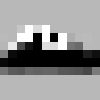
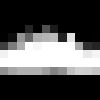
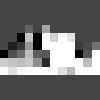
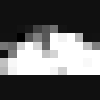
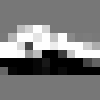
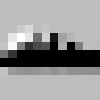
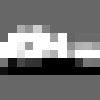
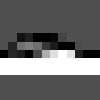

In [185]:
images = [net.propagate_to(test_x_normalized[test_image], "pool1", "image", channel=channel)
         for channel in range(8)]
original = test_x_normalized[test_image]
bigger = [image.resize((100,100),resample=0) for image in images]
gallery([original] + bigger, labels="channel{index}", gallery_shape=(9,1))

# Examine the results
Check which inputs the network is getting wrong. Recall that there are 10 thousand test images.

In [25]:
from numpy import argmax
outputs = net.predict(test_x_normalized)
answers = [argmax(output) for output in outputs]
targets = [argmax(target) for target in test_y_category]

/home/meeden/Envs/CS63env/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(10000, 28, 28, 1))
  warnings.warn(msg)


In [26]:
incorrect = [i for i in range(len(answers)) if answers[i] != targets[i]]
len(incorrect)

751

In [27]:
missed_target = [targets[i] for i in incorrect]
wrong_answer = [answers[i] for i in incorrect]

Let's find out which target classifications are most frequently missed.

In [28]:
from collections import Counter

In [29]:
t_ctr = Counter(missed_target)
t_ctr.most_common()

[(np.int64(4), 247),
 (np.int64(2), 167),
 (np.int64(3), 115),
 (np.int64(9), 56),
 (np.int64(5), 55),
 (np.int64(8), 45),
 (np.int64(7), 35),
 (np.int64(1), 31)]

Let's find out which wrong classification is most frequently given.

In [30]:
a_ctr = Counter(wrong_answer)
a_ctr.most_common()

[(np.int64(2), 334),
 (np.int64(4), 136),
 (np.int64(3), 102),
 (np.int64(7), 96),
 (np.int64(9), 31),
 (np.int64(5), 24),
 (np.int64(8), 23),
 (np.int64(1), 5)]

In [31]:
images = [array_to_image(test_x[index]) for index in incorrect]
label = [str(missed_target[i]) + "," + str(wrong_answer[i]) for i in range(len(wrong_answer))]
gallery(images, labels=label)

"4,2","5,7","9,5","4,2","3,2","4,2","3,4","9,7","2,4","4,2","9,7","4,2","2,3","4,2","4,3","2,3","4,2","4,2","3,2","3,4","4,2","9,7","8,2","4,2","4,3","4,2","4,3","9,7"
"2,4","2,4","3,2","4,2","9,5","5,7","3,2","4,2","4,2","8,2","4,2","3,1","3,2","4,2","3,2","8,2","4,2","4,2","1,3","4,3","3,2","4,2","8,2","1,3","2,3","5,7","3,2","4,2"
"4,2","1,3","7,9","4,2","2,4","5,7","4,2","8,2","2,4","4,2","2,4","3,2","3,2","5,7","4,2","2,4","4,2","2,4","5,8","4,2","4,2","2,4","4,3","8,2","4,2","2,3","2,4","4,2"
"5,7","4,3","2,4","4,2","2,4","4,2","2,3","8,2","4,2","8,5","2,4","3,2","4,2","4,2","2,4","4,2","4,2","4,2","2,4","8,2","4,2","9,7","1,3","5,7","2,3","8,2","9,7","2,4"
"5,7","9,7","2,4","2,8","1,3","4,2","3,4","4,2","2,4","2,4","2,4","4,2","3,4","4,3","3,2","8,2","3,4","4,2","4,2","4,2","4,2","9,7","2,3","5,7","9,7","1,3","2,4","3,2"
"8,3","2,4","4,2","3,2","7,9","5,7","2,4","4,2","4,2","3,4","4,3","3,4","2,4","1,3","4,2","2,4","4,2","4,2","3,4","4,2","4,2","3,2","2,4","4,2","3,2","3,2","4,2","2,4"
"2,8","1,2","4,2","3,4","4,2","8,7","4,2","8,2","1,3","4,2","3,4","4,2","9,7","7,9","2,4","2,3","9,7","7,9","2,8","4,2","2,3","3,4","8,2","4,2","3,2","3,2","3,2","4,3"
"3,2","1,3","7,5","4,2","4,3","3,2","4,2","3,2","3,2","2,8","4,2","2,8","3,4","3,4","8,3","7,9","3,2","4,2","5,7","9,7","4,2","1,3","7,9","2,3","7,5","3,2","8,3","3,2"
"2,4","2,3","3,2","3,2","8,7","4,2","4,3","9,7","4,2","4,2","2,3","3,2","5,7","4,3","4,2","4,3","2,4","3,4","4,2","4,3","8,2","2,4","3,2","3,2","4,2","2,3","2,4","4,2"
"9,7","2,9","2,3","3,4","2,5","8,7","3,2","4,2","5,9","2,3","2,4","2,3","4,2","4,2","4,3","4,2","2,4","2,4","5,7","3,2","4,3","4,2","7,5","9,7","2,4","8,2","4,2","3,2"
"4,2","3,2","9,7","4,2","4,3","2,4","2,3","2,4","5,9","4,2","2,3","9,7","2,4","3,4","3,2","3,2","1,3","4,2","2,4","8,2","9,5","7,5","2,4","4,2","2,4","5,7","2,3","9,7"


### Confusion matrix
Let's also build a confusion matrix to get a more precise idea of what mistakes are being made

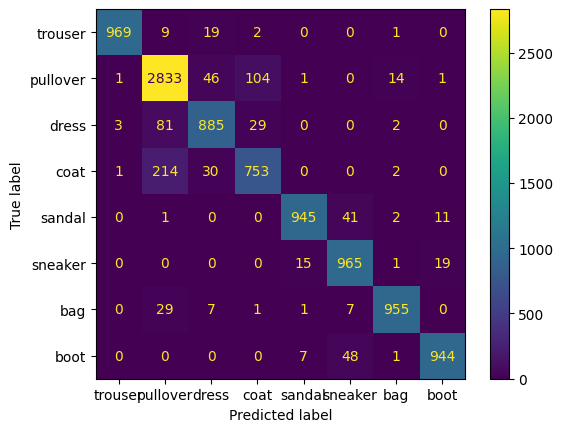

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(targets, answers)
label_map = ['trouser', 'pullover', 'dress', 'coat', 'sandal', 'sneaker', 'bag', 'boot']
cm_plt = ConfusionMatrixDisplay(cm, display_labels=label_map)
cm_plt.plot()
cm_plt.figure_.savefig('cm.png') 

# Analysis and Improvement

What sorts of mistakes are being made?  Do they make sense?  What sorts of things could you do to improve matters?

Notice here that some classes are performing a lot better than others; in particluar, the 'shirt' class seems to have a lot of overlap with 't-shirt', 'pull-over', and 'coat'.  'coat' and 'pullover' also seem to be easily confused.  

One possible thing to consider would be dropping and/or merging some of these classes if they seem like they really aren't distinct, but keep in mind that if you modify the data (or ideally, modify a *copy* of the data), you'll also need to modify the network and the labels to match, or nothing will work right.


Commom mistakes:
- the shirt is the most misclassified category. This is not surprising because shirt seems to be a really broadly-defined category and easily consufed with shifts, coat, etc.

Suggestions:
- ABBSOLUTELY get rid of shirts and pullovers. They are just not well categorized.
- Increase the size of epochs

Results:
- the accuracy improved from 86% to 92% by increasing the epoch to 10 and merging pullover and shirts into tshirts.
